In [1]:
import tensorflow as tf

print("TensorFlow:", tf.__version__)

gpu = tf.config.list_physical_devices("GPU")

if gpu:
    print("✅ GPU detected:")
    print(gpu)
else:
    print("❌ GPU not detected")

TensorFlow: 2.20.0
❌ GPU not detected


In [2]:
%pip -q install datasets

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
from datasets import load_dataset

dataset = load_dataset("tanganke/eurosat")

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 21600
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 2700
    })
    contrast: Dataset({
        features: ['image', 'label'],
        num_rows: 2700
    })
    gaussian_noise: Dataset({
        features: ['image', 'label'],
        num_rows: 2700
    })
    impulse_noise: Dataset({
        features: ['image', 'label'],
        num_rows: 2700
    })
    jpeg_compression: Dataset({
        features: ['image', 'label'],
        num_rows: 2700
    })
    motion_blur: Dataset({
        features: ['image', 'label'],
        num_rows: 2700
    })
    pixelate: Dataset({
        features: ['image', 'label'],
        num_rows: 2700
    })
    spatter: Dataset({
        features: ['image', 'label'],
        num_rows: 2700
    })
})


In [4]:
print(dataset["train"].features["label"].names)

['annual crop land', 'forest', 'brushland or shrubland', 'highway or road', 'industrial buildings or commercial buildings', 'pasture land', 'permanent crop land', 'residential buildings or homes or apartments', 'river', 'lake or sea']


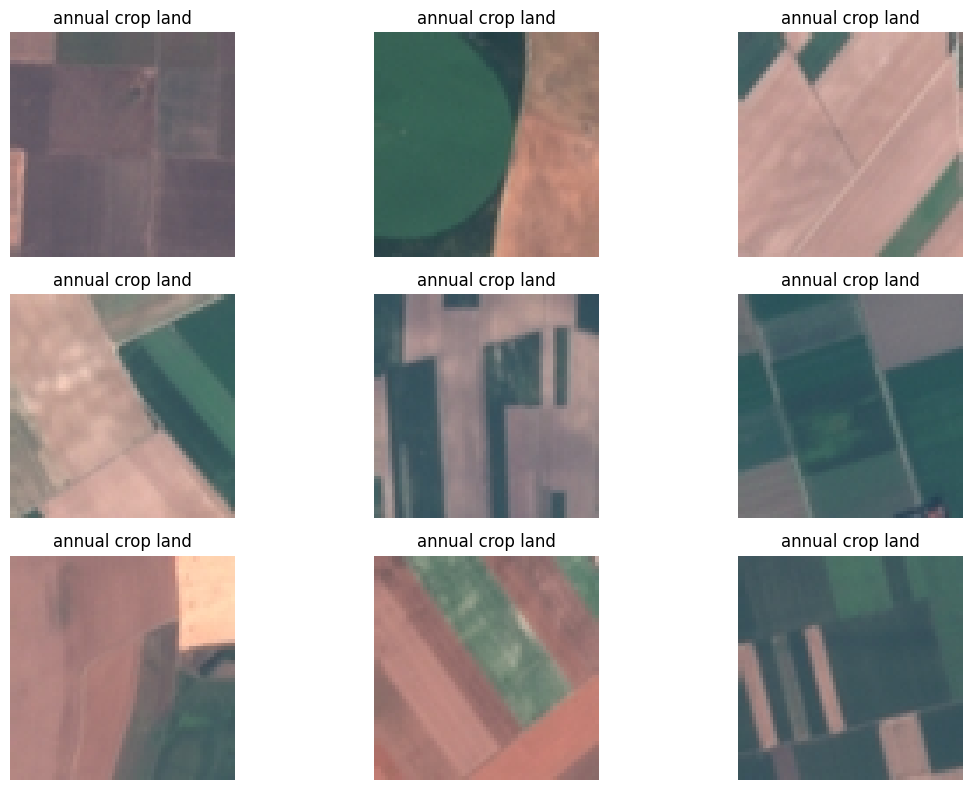

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

for i in range(9):
    sample = dataset["train"][i]

    plt.subplot(3, 3, i + 1)
    plt.imshow(sample["image"])
    plt.title(dataset["train"].features["label"].names[sample["label"]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [6]:
print("Total images:", len(dataset["train"]))

print("\nNumber of classes:",
      len(dataset["train"].features["label"].names))

print("\nClasses:")
for i, name in enumerate(dataset["train"].features["label"].names):
    print(f"{i}: {name}")

Total images: 21600

Number of classes: 10

Classes:
0: annual crop land
1: forest
2: brushland or shrubland
3: highway or road
4: industrial buildings or commercial buildings
5: pasture land
6: permanent crop land
7: residential buildings or homes or apartments
8: river
9: lake or sea


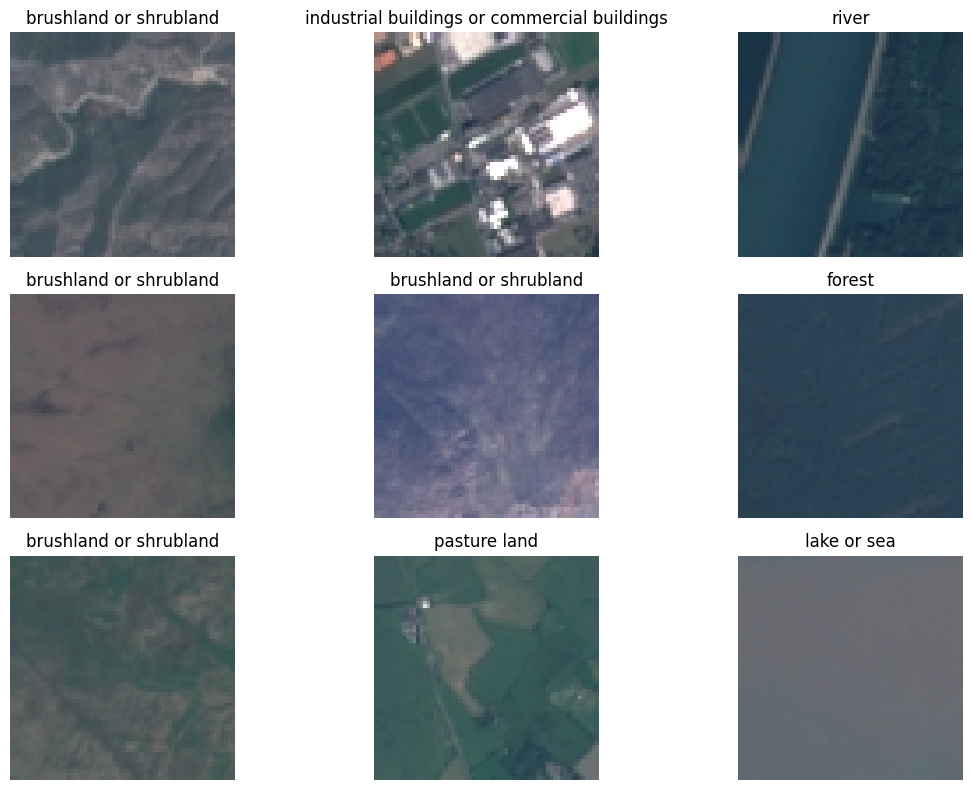

In [7]:
import matplotlib.pyplot as plt
import random

class_names = dataset["train"].features["label"].names

plt.figure(figsize=(12, 8))

random_indices = random.sample(range(len(dataset["train"])), 9)

for i, index in enumerate(random_indices):
    sample = dataset["train"][index]

    plt.subplot(3, 3, i + 1)
    plt.imshow(sample["image"])
    plt.title(class_names[sample["label"]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [8]:
print(dataset)

print("\nDataset splits:")
for split in dataset:
    print(split, "→", len(dataset[split]), "images")

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 21600
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 2700
    })
    contrast: Dataset({
        features: ['image', 'label'],
        num_rows: 2700
    })
    gaussian_noise: Dataset({
        features: ['image', 'label'],
        num_rows: 2700
    })
    impulse_noise: Dataset({
        features: ['image', 'label'],
        num_rows: 2700
    })
    jpeg_compression: Dataset({
        features: ['image', 'label'],
        num_rows: 2700
    })
    motion_blur: Dataset({
        features: ['image', 'label'],
        num_rows: 2700
    })
    pixelate: Dataset({
        features: ['image', 'label'],
        num_rows: 2700
    })
    spatter: Dataset({
        features: ['image', 'label'],
        num_rows: 2700
    })
})

Dataset splits:
train → 21600 images
test → 2700 images
contrast → 2700 images
gaussian_noise → 2700 images
impulse_noise → 2700 images
jpe

In [9]:
from sklearn.model_selection import train_test_split
import numpy as np

# Training dataset
train_data = dataset["train"]

# Create indices
indices = np.arange(len(train_data))

# 80% training, 20% validation
train_indices, val_indices = train_test_split(
    indices,
    test_size=0.20,
    random_state=42,
    stratify=train_data["label"]
)

print("Training images:", len(train_indices))
print("Validation images:", len(val_indices))
print("Test images:", len(dataset["test"]))

Training images: 17280
Validation images: 4320
Test images: 2700


In [10]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_data = dataset["train"].select(train_indices.tolist())
val_data = dataset["train"].select(val_indices.tolist())
test_data = dataset["test"]

print("Train:", len(train_data))
print("Validation:", len(val_data))
print("Test:", len(test_data))

Train: 17280
Validation: 4320
Test: 2700


In [11]:
def prepare_dataset(hf_dataset, shuffle=False):
    images = np.array([
        np.array(image.convert("RGB"))
        for image in hf_dataset["image"]
    ])

    labels = np.array(hf_dataset["label"])

    ds = tf.data.Dataset.from_tensor_slices((images, labels))

    if shuffle:
        ds = ds.shuffle(
            buffer_size=len(images),
            seed=42
        )

    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(tf.data.AUTOTUNE)

    return ds


train_ds = prepare_dataset(train_data, shuffle=True)
val_ds = prepare_dataset(val_data)
test_ds = prepare_dataset(test_data)

print("✅ TensorFlow datasets ready")

✅ TensorFlow datasets ready


In [12]:
for images, labels in train_ds.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("Image data type:", images.dtype)

Image batch shape: (32, 64, 64, 3)
Label batch shape: (32,)
Image data type: <dtype: 'uint8'>


In [13]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
], name="data_augmentation")

print("✅ Augmentation created")

✅ Augmentation created


In [14]:
IMG_SIZE = (224, 224)
NUM_CLASSES = 10

# Input: original EuroSAT image
inputs = keras.Input(shape=(64, 64, 3))

# Augmentation
x = data_augmentation(inputs)

# Resize 64x64 → 224x224
x = layers.Resizing(224, 224)(x)

# EfficientNetB0
base_model = keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

# Freeze pretrained layers initially
base_model.trainable = False

x = base_model(x, training=False)

# Classification head
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

model = keras.Model(inputs, outputs)

print("✅ EfficientNetB0 Model 1 created!")

✅ EfficientNetB0 Model 1 created!


In [15]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,062,381 (15.50 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [16]:
model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("✅ Model compiled")

✅ Model compiled


In [17]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-6
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks
)

Epoch 1/10


c:\Users\inaya\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


540/540 ━━━━━━━━━━━━━━━━━━━━ 287s 519ms/step - accuracy: 0.8170 - loss: 0.6155 - val_accuracy: 0.9037 - val_loss: 0.3076 - learning_rate: 0.0010
Epoch 2/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 279s 516ms/step - accuracy: 0.8888 - loss: 0.3398 - val_accuracy: 0.9109 - val_loss: 0.2735 - learning_rate: 0.0010
Epoch 3/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 272s 504ms/step - accuracy: 0.8948 - loss: 0.3102 - val_accuracy: 0.9204 - val_loss: 0.2483 - learning_rate: 0.0010
Epoch 4/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 274s 508ms/step - accuracy: 0.9033 - loss: 0.2878 - val_accuracy: 0.9218 - val_loss: 0.2305 - learning_rate: 0.0010
Epoch 5/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 272s 504ms/step - accuracy: 0.9099 - loss: 0.2696 - val_accuracy: 0.9243 - val_loss: 0.2252 - learning_rate: 0.0010
Epoch 6/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 273s 506ms/step - accuracy: 0.9089 - loss: 0.2680 - val_accuracy: 0.9248 - val_loss: 0.2252 - learning_rate: 0.0010
Epoch 7/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 268s 496ms/step - accuracy: 0.9133 

In [18]:
# Unfreeze the EfficientNet model
base_model.trainable = True

# Freeze the earlier layers
# Fine-tune only the last ~40 layers
for layer in base_model.layers[:-40]:
    layer.trainable = False

# Keep BatchNormalization layers frozen
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

print("Total layers:", len(base_model.layers))
print(
    "Trainable layers:",
    sum(layer.trainable for layer in base_model.layers)
)

Total layers: 238
Trainable layers: 32


In [19]:
model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("✅ Model recompiled for fine-tuning")

✅ Model recompiled for fine-tuning


In [20]:
fine_tune_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_accuracy",
            patience=5,
            mode="max",
            restore_best_weights=True
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.2,
            patience=2,
            min_lr=1e-7,
            verbose=1
        )
    ]
)

Epoch 1/15
540/540 ━━━━━━━━━━━━━━━━━━━━ 312s 557ms/step - accuracy: 0.9221 - loss: 0.2258 - val_accuracy: 0.9377 - val_loss: 0.1886 - learning_rate: 1.0000e-05
Epoch 2/15
540/540 ━━━━━━━━━━━━━━━━━━━━ 301s 558ms/step - accuracy: 0.9267 - loss: 0.2133 - val_accuracy: 0.9417 - val_loss: 0.1833 - learning_rate: 1.0000e-05
Epoch 3/15
540/540 ━━━━━━━━━━━━━━━━━━━━ 295s 546ms/step - accuracy: 0.9293 - loss: 0.2049 - val_accuracy: 0.9387 - val_loss: 0.1888 - learning_rate: 1.0000e-05
Epoch 4/15
540/540 ━━━━━━━━━━━━━━━━━━━━ 294s 544ms/step - accuracy: 0.9312 - loss: 0.1938 - val_accuracy: 0.9447 - val_loss: 0.1731 - learning_rate: 1.0000e-05
Epoch 5/15
540/540 ━━━━━━━━━━━━━━━━━━━━ 302s 560ms/step - accuracy: 0.9351 - loss: 0.1906 - val_accuracy: 0.9438 - val_loss: 0.1738 - learning_rate: 1.0000e-05
Epoch 6/15
540/540 ━━━━━━━━━━━━━━━━━━━━ 306s 567ms/step - accuracy: 0.9387 - loss: 0.1818 - val_accuracy: 0.9477 - val_loss: 0.1625 - learning_rate: 1.0000e-05
Epoch 7/15
540/540 ━━━━━━━━━━━━━━━━━━━━ 

In [21]:
# Unfreeze more EfficientNet layers
base_model.trainable = True

for layer in base_model.layers[:-100]:
    layer.trainable = False

# Keep BatchNormalization frozen
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

print("Total EfficientNet layers:", len(base_model.layers))
print(
    "Trainable EfficientNet layers:",
    sum(layer.trainable for layer in base_model.layers)
)

Total EfficientNet layers: 238
Trainable EfficientNet layers: 32


In [22]:
model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("✅ Ready for deeper fine-tuning")

✅ Ready for deeper fine-tuning


In [23]:
history_deep = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_accuracy",
            patience=5,
            mode="max",
            restore_best_weights=True
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.2,
            patience=2,
            min_lr=1e-7,
            verbose=1
        )
    ]
)

Epoch 1/15
540/540 ━━━━━━━━━━━━━━━━━━━━ 314s 563ms/step - accuracy: 0.9448 - loss: 0.1601 - val_accuracy: 0.9500 - val_loss: 0.1582 - learning_rate: 1.0000e-05
Epoch 2/15
540/540 ━━━━━━━━━━━━━━━━━━━━ 302s 559ms/step - accuracy: 0.9411 - loss: 0.1601 - val_accuracy: 0.9458 - val_loss: 0.1659 - learning_rate: 1.0000e-05
Epoch 3/15
540/540 ━━━━━━━━━━━━━━━━━━━━ 296s 548ms/step - accuracy: 0.9443 - loss: 0.1574 - val_accuracy: 0.9535 - val_loss: 0.1448 - learning_rate: 1.0000e-05
Epoch 4/15
540/540 ━━━━━━━━━━━━━━━━━━━━ 295s 546ms/step - accuracy: 0.9477 - loss: 0.1508 - val_accuracy: 0.9493 - val_loss: 0.1540 - learning_rate: 1.0000e-05
Epoch 5/15
540/540 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step - accuracy: 0.9462 - loss: 0.1572
Epoch 5: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.
540/540 ━━━━━━━━━━━━━━━━━━━━ 291s 539ms/step - accuracy: 0.9462 - loss: 0.1572 - val_accuracy: 0.9537 - val_loss: 0.1451 - learning_rate: 1.0000e-05
Epoch 6/15
540/540 ━━━━━━━━━━━━━━━━━━━━ 293s 5

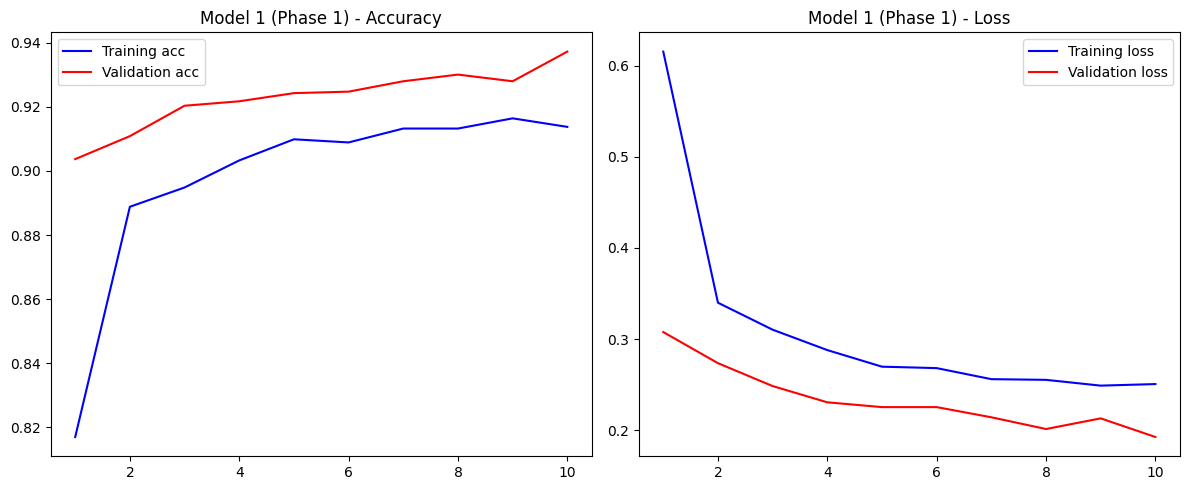

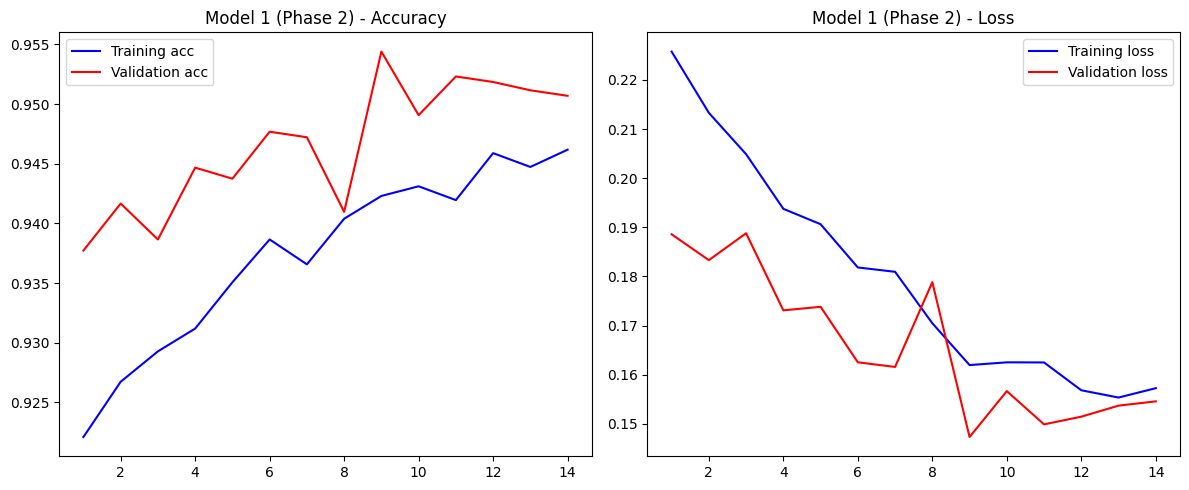

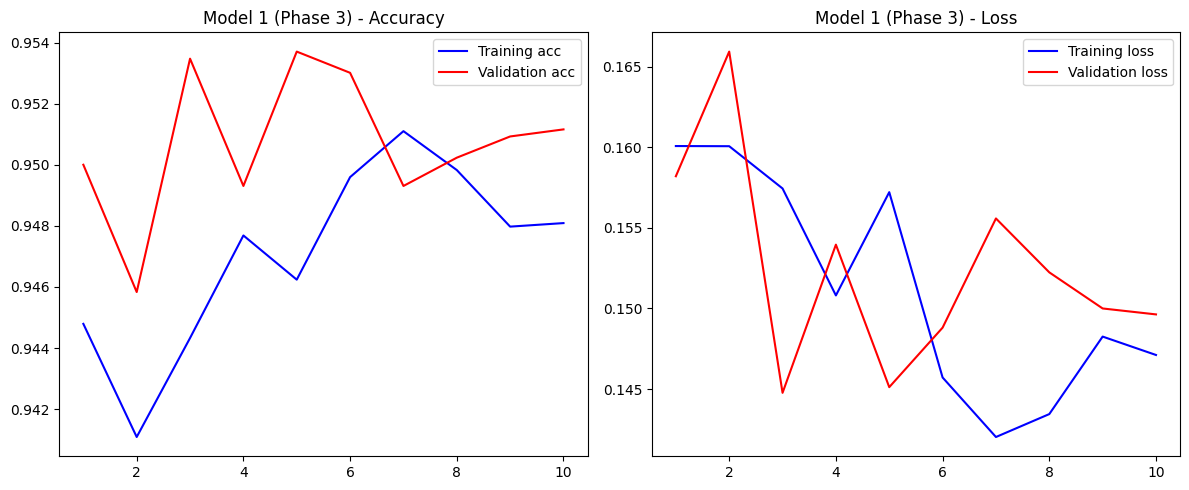

In [55]:
import matplotlib.pyplot as plt

def plot_history(history, title, filename):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'b', label='Training acc')
    plt.plot(epochs, val_acc, 'r', label='Validation acc')
    plt.title(title + ' - Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'b', label='Training loss')
    plt.plot(epochs, val_loss, 'r', label='Validation loss')
    plt.title(title + ' - Loss')
    plt.legend()
    plt.tight_layout()
    plt.savefig(filename)
    plt.show()

# Plot Model 1 Phase 1
plot_history(history, 'Model 1 (Phase 1)', 'model1_phase1_learning_curve.png')
# Plot Model 1 Phase 2
plot_history(fine_tune_history, 'Model 1 (Phase 2)', 'model1_phase2_learning_curve.png')
# Plot Model 1 Phase 3
plot_history(history_deep, 'Model 1 (Phase 3)', 'model1_phase3_learning_curve.png')


In [56]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("================================")
print("FINAL TEST RESULTS")
print("================================")
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy * 100:.2f}%")

85/85 ━━━━━━━━━━━━━━━━━━━━ 29s 345ms/step - accuracy: 0.9496 - loss: 0.1624
FINAL TEST RESULTS
Test Loss     : 0.1624
Test Accuracy : 94.96%


In [57]:
import numpy as np
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
))

                                              precision    recall  f1-score   support

                            annual crop land     0.9682    0.9590    0.9635       317
                                      forest     0.8883    0.9936    0.9380       312
                      brushland or shrubland     0.9752    0.8814    0.9259       312
                             highway or road     0.9662    0.9385    0.9522       244
industrial buildings or commercial buildings     0.9585    0.9957    0.9767       232
                                pasture land     0.9786    0.8883    0.9313       206
                         permanent crop land     0.9077    0.9498    0.9283       259
residential buildings or homes or apartments     0.9668    0.9962    0.9813       263
                                       river     0.9121    0.9765    0.9432       255
                                 lake or sea     1.0000    0.9167    0.9565       300

                                    accuracy        

<Figure size 1000x1000 with 0 Axes>

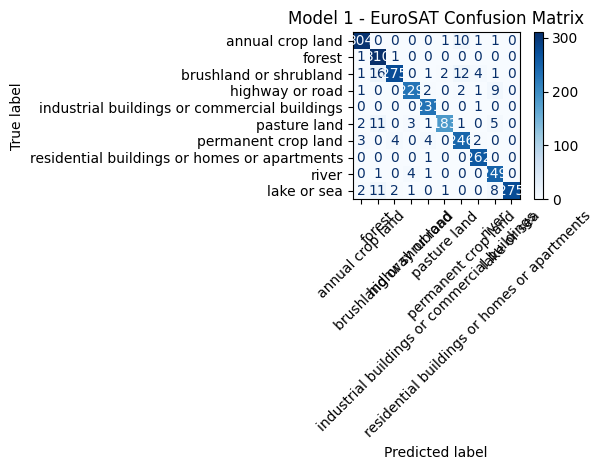

In [27]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    xticks_rotation=45,
    cmap="Blues"
)

plt.title("Model 1 - EuroSAT Confusion Matrix")
plt.tight_layout()
plt.savefig('model1_confusion_matrix.png')
plt.show()

In [28]:
import numpy as np

def extract_image_features(images):
    """
    Extract simple visual/site characteristics
    from satellite images.
    """

    images = images.astype("float32") / 255.0

    features = []

    for img in images:

        # RGB channels
        r = img[:, :, 0]
        g = img[:, :, 1]
        b = img[:, :, 2]

        # Basic image statistics
        mean_r = np.mean(r)
        mean_g = np.mean(g)
        mean_b = np.mean(b)

        brightness = np.mean(img)

        # Green/vegetation indicator
        vegetation = np.mean(
            (g > r * 1.05) & (g > b * 1.05)
        )

        # Water-like blue indicator
        water = np.mean(
            (b > r * 1.15) & (b > g * 1.05)
        )

        # Bright/built-up indicator
        built_up = np.mean(
            (r > 0.55) &
            (g > 0.55) &
            (b > 0.55)
        )

        # Road/accessibility proxy
        road_indicator = np.mean(
            (np.abs(r - g) < 0.12) &
            (np.abs(g - b) < 0.12) &
            (brightness > 0.45)
        )

        features.append([
            mean_r,
            mean_g,
            mean_b,
            brightness,
            vegetation,
            water,
            built_up,
            road_indicator
        ])

    return np.array(features)


print("✅ Feature extraction function created")

✅ Feature extraction function created


In [29]:
for images, labels in train_ds.take(1):

    sample_features = extract_image_features(
        images.numpy()
    )

    print("Feature shape:", sample_features.shape)

    print("\nFirst image features:")
    print(sample_features[0])

Feature shape: (32, 8)

First image features:
[0.2261872  0.29911822 0.35269704 0.29266748 0.         0.88696289
 0.00585938 0.        ]


In [30]:
# ============================================
# STEP 19 — CREATE MODEL 2 INPUT FEATURES
# ============================================

def create_model2_features(tf_dataset, model):

    all_features = []
    all_labels = []

    for images, labels in tf_dataset:

        # --------------------------------
        # 1. Extract 8 image features
        # --------------------------------
        image_features = extract_image_features(
            images.numpy()
        )

        # --------------------------------
        # 2. Get Model 1 probabilities
        # --------------------------------
        probabilities = model.predict(
            images,
            verbose=0
        )

        # --------------------------------
        # 3. Combine them
        # --------------------------------
        combined = np.concatenate(
            [image_features, probabilities],
            axis=1
        )

        all_features.append(combined)
        all_labels.append(labels.numpy())

    return (
        np.concatenate(all_features),
        np.concatenate(all_labels)
    )


print("Creating Model 2 features...")

Creating Model 2 features...


In [31]:
X_train_base, y_train_base = create_model2_features(
    train_ds,
    model
)

print("X_train shape:", X_train_base.shape)
print("y_train shape:", y_train_base.shape)

X_train shape: (17280, 18)
y_train shape: (17280,)


In [32]:
# ============================================
# STEP 21 — PROJECT-DEFINED SUITABILITY LABELS
# ============================================

def create_suitability_score(features, facility):

    # First 8 = image features
    brightness = features[:, 3]
    vegetation = features[:, 4]
    water = features[:, 5]
    built_up = features[:, 6]
    road = features[:, 7]

    # Next 10 = Model 1 class probabilities
    probs = features[:, 8:18]

    # Model 1 class indices
    annual_crop = probs[:, 0]
    forest = probs[:, 1]
    shrubland = probs[:, 2]
    highway = probs[:, 3]
    industrial = probs[:, 4]
    pasture = probs[:, 5]
    permanent_crop = probs[:, 6]
    residential = probs[:, 7]
    river = probs[:, 8]
    lake_sea = probs[:, 9]

    # -----------------------------------------
    # BANK SUITABILITY
    # -----------------------------------------
    if facility == "bank":

        score = (
            40 * residential +
            25 * industrial +
            15 * highway +
            8 * permanent_crop +
            5 * built_up +
            7 * road
        )

        # Penalize water / dense forest
        score -= 30 * river
        score -= 30 * lake_sea
        score -= 10 * forest

    # -----------------------------------------
    # COLLEGE SUITABILITY
    # -----------------------------------------
    elif facility == "college":

        score = (
            30 * residential +
            20 * pasture +
            15 * permanent_crop +
            15 * highway +
            10 * road +
            5 * annual_crop +
            5 * shrubland
        )

        # Penalize water / industrial / dense forest
        score -= 35 * river
        score -= 35 * lake_sea
        score -= 15 * industrial
        score -= 10 * forest

    else:
        raise ValueError("Facility must be bank or college")

    # Add small contribution from image characteristics
    score += 5 * built_up
    score += 5 * brightness

    # Normalize approximately to 0–100
    score = np.clip(score, 0, 100)

    return score


# Create scores
bank_scores = create_suitability_score(
    X_train_base,
    "bank"
)

college_scores = create_suitability_score(
    X_train_base,
    "college"
)

print("Bank scores:")
print(bank_scores[:10])

print("\nCollege scores:")
print(college_scores[:10])

Bank scores:
[17.36883971 41.84148431 13.01605711  5.76987926  0.         27.93590978
 41.73575259 13.9863261  17.17867514  9.53454863]

College scores:
[26.64706714 31.79163042 15.90854331 10.58294643  0.          0.
 31.66841807 21.31253463 16.9909936  16.53457483]


In [33]:
bank_labels = (bank_scores >= 60).astype(int)

college_labels = (college_scores >= 60).astype(int)

print("BANK")
print("Suitable:", np.sum(bank_labels == 1))
print("Not suitable:", np.sum(bank_labels == 0))

print("\nCOLLEGE")
print("Suitable:", np.sum(college_labels == 1))
print("Not suitable:", np.sum(college_labels == 0))

BANK
Suitable: 21
Not suitable: 17259

COLLEGE
Suitable: 0
Not suitable: 17280


In [34]:
import numpy as np

def create_suitability_score(features, facility):

    # Image features
    brightness = features[:, 3]
    vegetation = features[:, 4]
    water = features[:, 5]
    built_up = features[:, 6]
    road = features[:, 7]

    # Model 1 probabilities
    probs = features[:, 8:18]

    annual_crop = probs[:, 0]
    forest = probs[:, 1]
    shrubland = probs[:, 2]
    highway = probs[:, 3]
    industrial = probs[:, 4]
    pasture = probs[:, 5]
    permanent_crop = probs[:, 6]
    residential = probs[:, 7]
    river = probs[:, 8]
    lake_sea = probs[:, 9]

    if facility == "bank":

        score = (
            0.40 * residential +
            0.25 * industrial +
            0.20 * highway +
            0.10 * built_up +
            0.05 * road
        )

        score -= 0.40 * river
        score -= 0.40 * lake_sea
        score -= 0.15 * forest

    elif facility == "college":

        score = (
            0.30 * residential +
            0.20 * pasture +
            0.15 * permanent_crop +
            0.15 * highway +
            0.10 * annual_crop +
            0.05 * shrubland +
            0.05 * road
        )

        score -= 0.40 * river
        score -= 0.40 * lake_sea
        score -= 0.15 * industrial
        score -= 0.10 * forest

    else:
        raise ValueError("Facility must be bank or college")

    # Small visual contributions
    score += 0.05 * built_up
    score += 0.02 * brightness

    return score

In [35]:
bank_scores = create_suitability_score(
    X_train_base,
    "bank"
)

college_scores = create_suitability_score(
    X_train_base,
    "college"
)

print("BANK SCORE RANGE")
print("Minimum:", bank_scores.min())
print("Maximum:", bank_scores.max())
print("Mean:", bank_scores.mean())

print("\nCOLLEGE SCORE RANGE")
print("Minimum:", college_scores.min())
print("Maximum:", college_scores.max())
print("Mean:", college_scores.mean())

BANK SCORE RANGE
Minimum: -0.3966868398294515
Maximum: 0.6133365083298017
Mean: 0.020415837786610422

COLLEGE SCORE RANGE
Minimum: -0.39667200820602205
Maximum: 0.4138018580038818
Mean: 0.00855961679328121


In [36]:
bank_threshold = np.percentile(bank_scores, 60)
college_threshold = np.percentile(college_scores, 60)

bank_labels = (
    bank_scores >= bank_threshold
).astype(int)

college_labels = (
    college_scores >= college_threshold
).astype(int)

print("BANK")
print("Threshold:", bank_threshold)
print("Suitable:", np.sum(bank_labels == 1))
print("Not suitable:", np.sum(bank_labels == 0))

print("\nCOLLEGE")
print("Threshold:", college_threshold)
print("Suitable:", np.sum(college_labels == 1))
print("Not suitable:", np.sum(college_labels == 0))

BANK
Threshold: 0.0594987982007129
Suitable: 6912
Not suitable: 10368

COLLEGE
Threshold: 0.14012625274687066
Suitable: 6912
Not suitable: 10368


In [37]:
# ============================================
# STEP 24 — PREPARE MODEL 2 DATA
# ============================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

# Same satellite features, duplicated for the
# two facility types
X_bank = np.column_stack([
    X_train_base,
    np.zeros(len(X_train_base))   # 0 = Bank
])

X_college = np.column_stack([
    X_train_base,
    np.ones(len(X_train_base))    # 1 = College
])

# Combine Bank + College
X_model2 = np.vstack([
    X_bank,
    X_college
])

y_model2 = np.concatenate([
    bank_labels,
    college_labels
])

print("Model 2 feature shape:", X_model2.shape)
print("Model 2 label shape:", y_model2.shape)

print("\nTotal samples:", len(X_model2))
print("Suitable:", np.sum(y_model2 == 1))
print("Not suitable:", np.sum(y_model2 == 0))

Model 2 feature shape: (34560, 19)
Model 2 label shape: (34560,)

Total samples: 34560
Suitable: 13824
Not suitable: 20736


In [38]:
X2_train, X2_temp, y2_train, y2_temp = train_test_split(
    X_model2,
    y_model2,
    test_size=0.20,
    random_state=42,
    stratify=y_model2
)

X2_val, X2_test, y2_val, y2_test = train_test_split(
    X2_temp,
    y2_temp,
    test_size=0.50,
    random_state=42,
    stratify=y2_temp
)

print("Training:", X2_train.shape)
print("Validation:", X2_val.shape)
print("Testing:", X2_test.shape)

Training: (27648, 19)
Validation: (3456, 19)
Testing: (3456, 19)


In [39]:
scaler = StandardScaler()

X2_train = scaler.fit_transform(X2_train)

X2_val = scaler.transform(X2_val)

X2_test = scaler.transform(X2_test)

print("✅ Model 2 features normalized")

✅ Model 2 features normalized


In [40]:
from tensorflow import keras
from tensorflow.keras import layers

model2 = keras.Sequential([

    layers.Input(shape=(19,)),

    layers.Dense(128, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(64, activation="relu"),
    layers.Dropout(0.2),

    layers.Dense(32, activation="relu"),

    layers.Dense(1, activation="sigmoid")
])

model2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 128)            │         2,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,441 (52.50 KB)

 Trainable params: 13,185 (51.50 KB)

 Non-trainable params: 256 (1.00 KB)

In [41]:
model2.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall")
    ]
)

print("✅ Model 2 compiled")

✅ Model 2 compiled


In [42]:
history2 = model2.fit(
    X2_train,
    y2_train,
    validation_data=(X2_val, y2_val),
    epochs=30,
    batch_size=64,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            min_lr=1e-6,
            verbose=1
        )
    ]
)

Epoch 1/30
432/432 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9506 - loss: 0.1231 - precision: 0.9282 - recall: 0.9500 - val_accuracy: 0.9887 - val_loss: 0.0365 - val_precision: 0.9800 - val_recall: 0.9920 - learning_rate: 0.0010
Epoch 2/30
432/432 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9810 - loss: 0.0527 - precision: 0.9725 - recall: 0.9803 - val_accuracy: 0.9899 - val_loss: 0.0282 - val_precision: 0.9828 - val_recall: 0.9920 - learning_rate: 0.0010
Epoch 3/30
432/432 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9849 - loss: 0.0401 - precision: 0.9783 - recall: 0.9840 - val_accuracy: 0.9902 - val_loss: 0.0243 - val_precision: 0.9821 - val_recall: 0.9935 - learning_rate: 0.0010
Epoch 4/30
432/432 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9867 - loss: 0.0340 - precision: 0.9807 - recall: 0.9862 - val_accuracy: 0.9925 - val_loss: 0.0202 - val_precision: 0.9913 - val_recall: 0.9899 - learning_rate: 0.0010
Epoch 5/30
432/432 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 

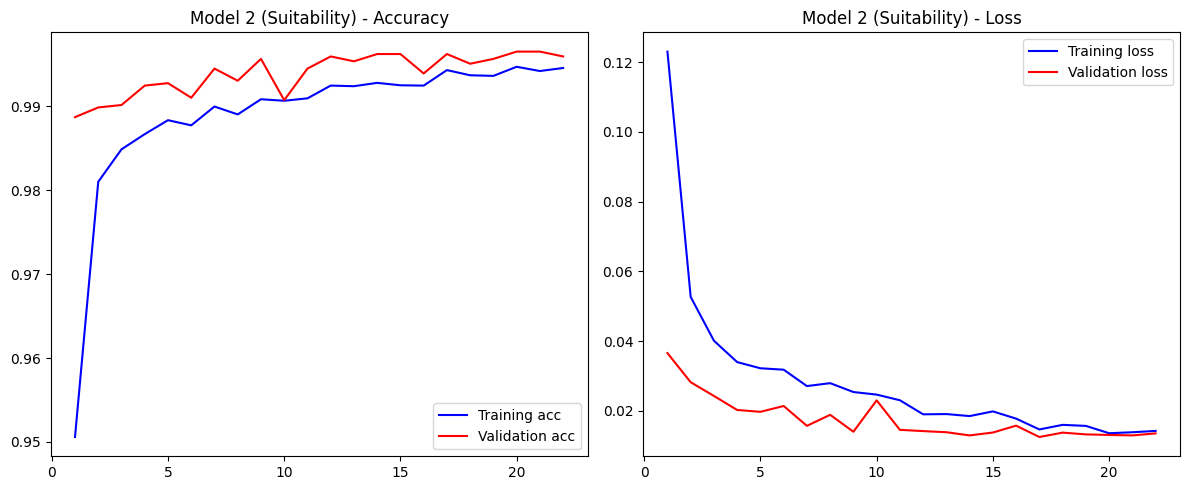

In [43]:
plot_history(history2, 'Model 2 (Suitability)', 'model2_learning_curve.png')


In [44]:
model2_results = model2.evaluate(
    X2_test,
    y2_test,
    verbose=1
)

print("\n==============================")
print("MODEL 2 TEST RESULTS")
print("==============================")

for name, value in zip(model2.metrics_names, model2_results):
    print(f"{name}: {value:.4f}")

108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9951 - loss: 0.0133 - precision: 0.9907 - recall: 0.9971

MODEL 2 TEST RESULTS
loss: 0.0133
compile_metrics: 0.9951


In [45]:
from sklearn.metrics import classification_report

y2_prob = model2.predict(
    X2_test,
    verbose=0
).ravel()

y2_pred = (y2_prob >= 0.5).astype(int)

print(classification_report(
    y2_test,
    y2_pred,
    target_names=["Not Suitable", "Suitable"],
    digits=4
))

              precision    recall  f1-score   support

Not Suitable     0.9981    0.9937    0.9959      2074
    Suitable     0.9907    0.9971    0.9939      1382

    accuracy                         0.9951      3456
   macro avg     0.9944    0.9954    0.9949      3456
weighted avg     0.9951    0.9951    0.9951      3456



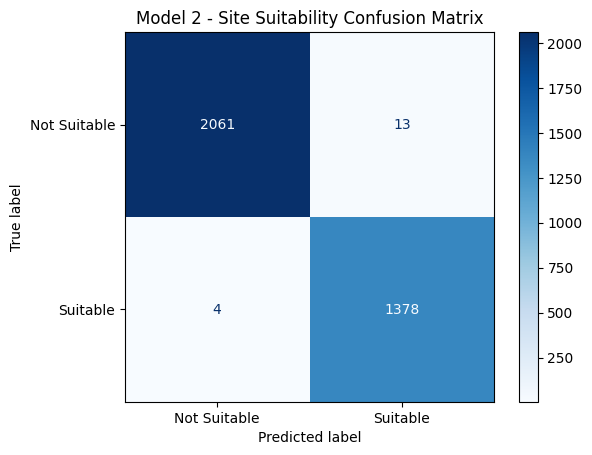

In [46]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm2 = confusion_matrix(y2_test, y2_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm2,
    display_labels=["Not Suitable", "Suitable"]
)

disp.plot(cmap="Blues")

plt.title("Model 2 - Site Suitability Confusion Matrix")
plt.savefig('model2_confusion_matrix.png')
plt.show()

In [47]:
model.save("./model1_efficientnet.keras")
model2.save("./model2_suitability.keras")

print("✅ Model 1 saved")
print("✅ Model 2 saved")

✅ Model 1 saved
✅ Model 2 saved


In [48]:
import joblib

joblib.dump(
    scaler,
    "./model2_scaler.pkl"
)

print("✅ Model 2 scaler saved")

✅ Model 2 scaler saved


In [49]:
# ============================================
# STEP 34 — FINAL PREDICTION FUNCTION
# ============================================

import numpy as np
import tensorflow as tf
from tensorflow import keras

# Make sure the trained models exist
print("Model 1:", model.name)
print("Model 2:", model2.name)

class_names = dataset["train"].features["label"].names

print("\nClasses:")
for i, name in enumerate(class_names):
    print(i, ":", name)

print("\n✅ Models ready")

Model 1: functional_1
Model 2: sequential

Classes:
0 : annual crop land
1 : forest
2 : brushland or shrubland
3 : highway or road
4 : industrial buildings or commercial buildings
5 : pasture land
6 : permanent crop land
7 : residential buildings or homes or apartments
8 : river
9 : lake or sea

✅ Models ready


In [50]:
def predict_site(image, facility="bank"):

    # -----------------------------------------
    # Convert image to RGB
    # -----------------------------------------
    image = image.convert("RGB")

    # Original 64x64 image for Model 1
    img_array = np.array(image.resize((64, 64)))

    img_batch = np.expand_dims(img_array, axis=0)

    # -----------------------------------------
    # MODEL 1 — Land-use classification
    # -----------------------------------------
    probabilities = model.predict(
        img_batch,
        verbose=0
    )[0]

    predicted_class = np.argmax(probabilities)

    predicted_name = class_names[predicted_class]

    confidence = probabilities[predicted_class]

    # -----------------------------------------
    # Extract 8 visual features
    # -----------------------------------------
    image_features = extract_image_features(
        img_batch
    )

    # -----------------------------------------
    # Combine:
    # 8 visual + 10 Model 1 probabilities
    # -----------------------------------------
    combined_features = np.concatenate(
        [image_features, probabilities.reshape(1, -1)],
        axis=1
    )

    # -----------------------------------------
    # Facility indicator
    # -----------------------------------------
    facility_value = 0 if facility.lower() == "bank" else 1

    model2_input = np.column_stack([
        combined_features,
        [facility_value]
    ])

    # -----------------------------------------
    # Scale Model 2 input
    # -----------------------------------------
    model2_input = scaler.transform(
        model2_input
    )

    # -----------------------------------------
    # MODEL 2
    # -----------------------------------------
    suitability_probability = model2.predict(
        model2_input,
        verbose=0
    )[0][0]

    # -----------------------------------------
    # Final decision
    # -----------------------------------------
    if suitability_probability >= 0.5:
        decision = "SUITABLE"
    else:
        decision = "NOT SUITABLE"

    return {
        "land_type": predicted_name,
        "land_confidence": float(confidence),
        "facility": facility.upper(),
        "suitability": float(suitability_probability),
        "decision": decision
    }

print("✅ Prediction function created")

✅ Prediction function created


In [51]:
sample = dataset["test"][0]

result = predict_site(
    sample["image"],
    facility="bank"
)

print("================================")
print("SITE ANALYSIS")
print("================================")

print("Land Type     :", result["land_type"])
print("Confidence    :", f"{result['land_confidence']*100:.2f}%")
print("Facility      :", result["facility"])
print("Suitability   :", f"{result['suitability']*100:.2f}%")
print("Decision      :", result["decision"])

SITE ANALYSIS
Land Type     : annual crop land
Confidence    : 99.99%
Facility      : BANK
Suitability   : 99.71%
Decision      : SUITABLE


In [52]:
result = predict_site(
    sample["image"],
    facility="college"
)

print("================================")
print("SITE ANALYSIS")
print("================================")

print("Land Type     :", result["land_type"])
print("Confidence    :", f"{result['land_confidence']*100:.2f}%")
print("Facility      :", result["facility"])
print("Suitability   :", f"{result['suitability']*100:.2f}%")
print("Decision      :", result["decision"])

SITE ANALYSIS
Land Type     : annual crop land
Confidence    : 99.99%
Facility      : COLLEGE
Suitability   : 99.58%
Decision      : SUITABLE


True class: annual crop land
Image size: (64, 64)


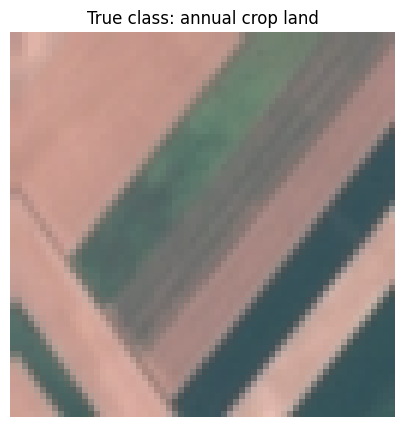

In [53]:
import matplotlib.pyplot as plt

# Take the first image from the EuroSAT test set
sample = dataset["test"][0]

test_image = sample["image"]
true_label = sample["label"]

print("True class:", class_names[true_label])
print("Image size:", test_image.size)

plt.figure(figsize=(5, 5))
plt.imshow(test_image)
plt.axis("off")
plt.title(f"True class: {class_names[true_label]}")
plt.show()

In [54]:
result = predict_site(
    test_image,
    facility="bank"
)

print("\n======================================")
print("       🛰️ SITE SUITABILITY RESULT")
print("======================================")

print(f"Actual Land Type : {class_names[true_label]}")
print(f"Predicted Type   : {result['land_type']}")
print(f"Model 1 Confidence: {result['land_confidence']*100:.2f}%")

print("--------------------------------------")

print(f"Facility         : 🏦 {result['facility']}")
print(f"Suitability      : {result['suitability']*100:.2f}%")
print(f"Final Decision   : {result['decision']}")

print("======================================")


       🛰️ SITE SUITABILITY RESULT
Actual Land Type : annual crop land
Predicted Type   : annual crop land
Model 1 Confidence: 99.99%
--------------------------------------
Facility         : 🏦 BANK
Suitability      : 99.71%
Final Decision   : SUITABLE


In [59]:
# ============================================
# MODEL 3 — RECOMMENDATION CLASSES
# ============================================

MODEL3_CLASSES = [
    "Residential Development",
    "Commercial Development",
    "Industrial Development",
    "Educational Development",
    "Healthcare Development",
    "Agricultural Use",
    "Transportation Infrastructure",
    "Green / Conservation"
]

print("Model 3 Classes:")
for i, name in enumerate(MODEL3_CLASSES):
    print(i, ":", name)

print("\nTotal recommendation classes:", len(MODEL3_CLASSES))

Model 3 Classes:
0 : Residential Development
1 : Commercial Development
2 : Industrial Development
3 : Educational Development
4 : Healthcare Development
5 : Agricultural Use
6 : Transportation Infrastructure
7 : Green / Conservation

Total recommendation classes: 8


In [60]:
# ============================================
# MODEL 3 — FEATURE EXTRACTION
# ============================================

def prepare_model3_features(X_base):

    X_base = np.asarray(X_base)

    if X_base.shape[1] != 18:
        raise ValueError(
            f"Expected 18 base features, got {X_base.shape[1]}"
        )

    return X_base.astype("float32")


X_model3_base = prepare_model3_features(
    X_train_base
)

print("Model 3 input shape:", X_model3_base.shape)

Model 3 input shape: (17280, 18)


In [61]:
# ============================================
# MODEL 3 — PROJECT-DEFINED RECOMMENDATION SCORES
# ============================================

def create_model3_scores(features):

    # -----------------------------------------
    # 8 IMAGE FEATURES
    # -----------------------------------------

    mean_r = features[:, 0]
    mean_g = features[:, 1]
    mean_b = features[:, 2]

    brightness = features[:, 3]
    vegetation = features[:, 4]
    water = features[:, 5]
    built_up = features[:, 6]
    road = features[:, 7]

    # -----------------------------------------
    # 10 MODEL 1 PROBABILITIES
    # -----------------------------------------

    probs = features[:, 8:18]

    annual_crop = probs[:, 0]
    forest = probs[:, 1]
    shrubland = probs[:, 2]
    highway = probs[:, 3]
    industrial = probs[:, 4]
    pasture = probs[:, 5]
    permanent_crop = probs[:, 6]
    residential = probs[:, 7]
    river = probs[:, 8]
    lake_sea = probs[:, 9]

    # -----------------------------------------
    # 1. RESIDENTIAL
    # -----------------------------------------

    residential_score = (
        0.35 * residential +
        0.15 * built_up +
        0.15 * highway +
        0.10 * road +
        0.10 * brightness +
        0.05 * permanent_crop +
        0.10 * annual_crop
    )

    residential_score -= (
        0.40 * river +
        0.40 * lake_sea +
        0.15 * forest
    )

    # -----------------------------------------
    # 2. COMMERCIAL
    # -----------------------------------------

    commercial_score = (
        0.30 * built_up +
        0.25 * residential +
        0.20 * highway +
        0.15 * road +
        0.10 * brightness
    )

    commercial_score -= (
        0.40 * river +
        0.40 * lake_sea +
        0.15 * forest
    )

    # -----------------------------------------
    # 3. INDUSTRIAL
    # -----------------------------------------

    industrial_score = (
        0.40 * industrial +
        0.20 * built_up +
        0.15 * highway +
        0.10 * road +
        0.10 * brightness +
        0.05 * annual_crop
    )

    industrial_score -= (
        0.40 * river +
        0.40 * lake_sea +
        0.20 * forest
    )

    # -----------------------------------------
    # 4. EDUCATIONAL
    # -----------------------------------------

    educational_score = (
        0.25 * residential +
        0.20 * pasture +
        0.15 * permanent_crop +
        0.15 * highway +
        0.10 * road +
        0.10 * built_up +
        0.05 * annual_crop
    )

    educational_score -= (
        0.40 * river +
        0.40 * lake_sea +
        0.15 * industrial +
        0.10 * forest
    )

    # -----------------------------------------
    # 5. HEALTHCARE
    # -----------------------------------------

    healthcare_score = (
        0.30 * residential +
        0.20 * built_up +
        0.20 * highway +
        0.15 * road +
        0.10 * brightness +
        0.05 * pasture
    )

    healthcare_score -= (
        0.40 * river +
        0.40 * lake_sea +
        0.20 * industrial +
        0.15 * forest
    )

    # -----------------------------------------
    # 6. AGRICULTURAL USE
    # -----------------------------------------

    agricultural_score = (
        0.35 * annual_crop +
        0.25 * permanent_crop +
        0.20 * pasture +
        0.10 * shrubland +
        0.10 * vegetation
    )

    agricultural_score -= (
        0.30 * built_up +
        0.20 * industrial +
        0.15 * highway +
        0.40 * lake_sea
    )

    # -----------------------------------------
    # 7. TRANSPORTATION
    # -----------------------------------------

    transportation_score = (
        0.40 * highway +
        0.25 * road +
        0.15 * built_up +
        0.10 * industrial +
        0.10 * brightness
    )

    transportation_score -= (
        0.40 * river +
        0.40 * lake_sea +
        0.20 * forest
    )

    # -----------------------------------------
    # 8. GREEN / CONSERVATION
    # -----------------------------------------

    green_score = (
        0.35 * forest +
        0.20 * vegetation +
        0.15 * pasture +
        0.10 * shrubland +
        0.10 * permanent_crop +
        0.10 * water
    )

    # Conservation becomes especially relevant
    # around water and natural vegetation.
    green_score += (
        0.15 * river +
        0.15 * lake_sea
    )

    green_score -= (
        0.20 * industrial +
        0.15 * built_up
    )

    # -----------------------------------------
    # COMBINE
    # -----------------------------------------

    scores = np.column_stack([
        residential_score,
        commercial_score,
        industrial_score,
        educational_score,
        healthcare_score,
        agricultural_score,
        transportation_score,
        green_score
    ])

    # Keep scores non-negative
    scores = np.clip(scores, 0, None)

    return scores


model3_scores = create_model3_scores(
    X_model3_base
)

print("Model 3 score shape:", model3_scores.shape)

print("\nFirst sample scores:")

for name, score in zip(
    MODEL3_CLASSES,
    model3_scores[0]
):
    print(
        f"{name:35s}: {score:.4f}"
    )

Model 3 score shape: (17280, 8)

First sample scores:
Residential Development            : 0.1975
Commercial Development             : 0.2046
Industrial Development             : 0.1516
Educational Development            : 0.2478
Healthcare Development             : 0.1964
Agricultural Use                   : 0.2311
Transportation Infrastructure      : 0.2819
Green / Conservation               : 0.0993


In [62]:
# ============================================
# MODEL 3 — CREATE TARGET LABELS
# ============================================

y_model3 = np.argmax(
    model3_scores,
    axis=1
)

print("Model 3 target shape:", y_model3.shape)

print("\nTarget distribution:")

for i, name in enumerate(MODEL3_CLASSES):

    count = np.sum(y_model3 == i)

    percentage = (
        count / len(y_model3)
    ) * 100

    print(
        f"{i}: {name:35s} "
        f"{count:6d} samples "
        f"({percentage:.2f}%)"
    )

Model 3 target shape: (17280,)

Target distribution:
0: Residential Development               1717 samples (9.94%)
1: Commercial Development                 526 samples (3.04%)
2: Industrial Development                1646 samples (9.53%)
3: Educational Development                 47 samples (0.27%)
4: Healthcare Development                 331 samples (1.92%)
5: Agricultural Use                      3050 samples (17.65%)
6: Transportation Infrastructure         2637 samples (15.26%)
7: Green / Conservation                  7326 samples (42.40%)


In [63]:
# ============================================
# MODEL 3 — SCORE DISTRIBUTION ANALYSIS
# ============================================

print("MODEL 3 SCORE STATISTICS")
print("=" * 60)

for i, name in enumerate(MODEL3_CLASSES):

    scores = model3_scores[:, i]

    print(f"\n{name}")
    print(f"  Min    : {scores.min():.4f}")
    print(f"  Max    : {scores.max():.4f}")
    print(f"  Mean   : {scores.mean():.4f}")
    print(f"  Median : {np.median(scores):.4f}")

MODEL 3 SCORE STATISTICS

Residential Development
  Min    : 0.0000
  Max    : 0.6744
  Mean   : 0.1271
  Median : 0.0725

Commercial Development
  Min    : 0.0000
  Max    : 0.7719
  Mean   : 0.1262
  Median : 0.0414

Industrial Development
  Min    : 0.0000
  Max    : 0.7624
  Mean   : 0.1187
  Median : 0.0389

Educational Development
  Min    : 0.0000
  Max    : 0.4472
  Mean   : 0.0926
  Median : 0.0462

Healthcare Development
  Min    : 0.0000
  Max    : 0.7222
  Mean   : 0.1121
  Median : 0.0422

Agricultural Use
  Min    : 0.0000
  Max    : 0.4452
  Mean   : 0.0763
  Median : 0.0000

Transportation Infrastructure
  Min    : 0.0000
  Max    : 0.8308
  Mean   : 0.1308
  Median : 0.0375

Green / Conservation
  Min    : 0.0000
  Max    : 0.5494
  Mean   : 0.1501
  Median : 0.1072


In [64]:
# ============================================
# TOP RECOMMENDATION CONFIDENCE
# ============================================

top_scores = np.max(model3_scores, axis=1)

print("\n" + "=" * 60)
print("TOP RECOMMENDATION SCORE")
print("=" * 60)

print(f"Minimum : {top_scores.min():.4f}")
print(f"Maximum : {top_scores.max():.4f}")
print(f"Mean    : {top_scores.mean():.4f}")
print(f"Median  : {np.median(top_scores):.4f}")


TOP RECOMMENDATION SCORE
Minimum : 0.0466
Maximum : 0.8308
Mean    : 0.3387
Median  : 0.3240


In [65]:
# ============================================
# MODEL 3 — INSPECT LAND → RECOMMENDATION MAP
# ============================================

land_names = [
    "Annual Crop Land",
    "Forest",
    "Brushland or Shrubland",
    "Highway or Road",
    "Industrial Buildings or Commercial Buildings",
    "Pasture Land",
    "Permanent Crop Land",
    "Residential Buildings or Homes or Apartments",
    "River",
    "Lake or Sea"
]

print("=" * 75)
print("LAND CLASS → CURRENT MODEL 3 RECOMMENDATION DISTRIBUTION")
print("=" * 75)

predicted_land = np.argmax(
    X_model3_base[:, 8:18],
    axis=1
)

for land_idx, land_name in enumerate(land_names):

    mask = predicted_land == land_idx

    if np.sum(mask) == 0:
        continue

    recommendations = y_model3[mask]

    print(f"\n{land_name}")
    print(f"Samples: {len(recommendations)}")

    for rec_idx, rec_name in enumerate(MODEL3_CLASSES):

        count = np.sum(recommendations == rec_idx)

        if count > 0:
            pct = count / len(recommendations) * 100
            print(
                f"  {rec_name:35s} "
                f"{count:5d} ({pct:5.1f}%)"
            )

LAND CLASS → CURRENT MODEL 3 RECOMMENDATION DISTRIBUTION

Annual Crop Land
Samples: 1821
  Residential Development               181 (  9.9%)
  Commercial Development                218 ( 12.0%)
  Agricultural Use                     1330 ( 73.0%)
  Transportation Infrastructure          87 (  4.8%)
  Green / Conservation                    5 (  0.3%)

Forest
Samples: 2103
  Green / Conservation                 2103 (100.0%)

Brushland or Shrubland
Samples: 1824
  Residential Development                10 (  0.5%)
  Commercial Development                 51 (  2.8%)
  Healthcare Development                  3 (  0.2%)
  Agricultural Use                      156 (  8.6%)
  Transportation Infrastructure         401 ( 22.0%)
  Green / Conservation                 1203 ( 66.0%)

Highway or Road
Samples: 1568
  Industrial Development                  1 (  0.1%)
  Agricultural Use                        1 (  0.1%)
  Transportation Infrastructure        1540 ( 98.2%)
  Green / Conservation   

In [66]:
# ============================================
# MODEL 3 — RECOMMENDATION CLASSES
# ============================================

MODEL3_CLASSES = [
    "Residential Development",
    "Commercial Development",
    "Industrial Development",
    "Educational Development",
    "Healthcare Development",
    "Agricultural Use",
    "Transportation Infrastructure",
    "Green / Conservation"
]

print("MODEL 3 RECOMMENDATION CLASSES")
print("=" * 50)

for i, name in enumerate(MODEL3_CLASSES):
    print(f"{i}: {name}")

MODEL 3 RECOMMENDATION CLASSES
0: Residential Development
1: Commercial Development
2: Industrial Development
3: Educational Development
4: Healthcare Development
5: Agricultural Use
6: Transportation Infrastructure
7: Green / Conservation


In [67]:
# ============================================
# MODEL 3 — IMPROVED RECOMMENDATION SCORING
# ============================================

def create_model3_scores_v2(features):

    # -----------------------------------------
    # MODEL 1 PROBABILITIES
    # -----------------------------------------

    probs = features[:, 8:18]

    annual_crop = probs[:, 0]
    forest = probs[:, 1]
    shrubland = probs[:, 2]
    highway = probs[:, 3]
    industrial = probs[:, 4]
    pasture = probs[:, 5]
    permanent_crop = probs[:, 6]
    residential = probs[:, 7]
    river = probs[:, 8]
    lake_sea = probs[:, 9]

    # -----------------------------------------
    # VISUAL FEATURES
    # -----------------------------------------

    brightness = features[:, 3]
    vegetation = features[:, 4]
    water = features[:, 5]
    built_up = features[:, 6]
    road = features[:, 7]

    # =========================================
    # RESIDENTIAL
    # =========================================

    residential_score = (
        0.65 * residential +
        0.15 * built_up +
        0.10 * highway +
        0.05 * road +
        0.05 * brightness
    )

    residential_score -= (
        0.50 * river +
        0.50 * lake_sea +
        0.20 * forest
    )

    # =========================================
    # COMMERCIAL
    # =========================================

    commercial_score = (
        0.40 * residential +
        0.25 * industrial +
        0.20 * highway +
        0.10 * built_up +
        0.05 * road
    )

    commercial_score -= (
        0.45 * river +
        0.45 * lake_sea +
        0.15 * forest
    )

    # =========================================
    # INDUSTRIAL
    # =========================================

    industrial_score = (
        0.65 * industrial +
        0.15 * highway +
        0.10 * built_up +
        0.10 * road
    )

    industrial_score -= (
        0.50 * river +
        0.50 * lake_sea +
        0.25 * forest
    )

    # =========================================
    # EDUCATIONAL
    # =========================================

    educational_score = (
        0.40 * residential +
        0.20 * pasture +
        0.15 * highway +
        0.10 * permanent_crop +
        0.10 * built_up +
        0.05 * road
    )

    educational_score -= (
        0.45 * river +
        0.45 * lake_sea +
        0.20 * industrial
    )

    # =========================================
    # HEALTHCARE
    # =========================================

    healthcare_score = (
        0.45 * residential +
        0.20 * built_up +
        0.15 * highway +
        0.10 * road +
        0.10 * pasture
    )

    healthcare_score -= (
        0.50 * river +
        0.50 * lake_sea +
        0.25 * industrial
    )

    # =========================================
    # AGRICULTURAL
    # =========================================

    agricultural_score = (
        0.45 * annual_crop +
        0.25 * permanent_crop +
        0.15 * pasture +
        0.10 * vegetation +
        0.05 * shrubland
    )

    agricultural_score -= (
        0.35 * industrial +
        0.25 * built_up +
        0.15 * highway
    )

    # =========================================
    # TRANSPORTATION
    # =========================================

    transportation_score = (
        0.55 * highway +
        0.20 * road +
        0.10 * industrial +
        0.10 * built_up +
        0.05 * brightness
    )

    transportation_score -= (
        0.35 * river +
        0.35 * lake_sea +
        0.15 * forest
    )

    # =========================================
    # GREEN / CONSERVATION
    # =========================================

    green_score = (
        0.45 * forest +
        0.20 * shrubland +
        0.15 * pasture +
        0.10 * vegetation +
        0.05 * river +
        0.05 * lake_sea
    )

    green_score -= (
        0.20 * industrial +
        0.15 * built_up
    )

    # =========================================
    # COMBINE
    # =========================================

    scores = np.column_stack([
        residential_score,
        commercial_score,
        industrial_score,
        educational_score,
        healthcare_score,
        agricultural_score,
        transportation_score,
        green_score
    ])

    # No negative suitability
    scores = np.clip(scores, 0, None)

    return scores


model3_scores_v2 = create_model3_scores_v2(
    X_model3_base
)

print("Model 3 score matrix:")
print(model3_scores_v2.shape)

Model 3 score matrix:
(17280, 8)


In [68]:
# ============================================
# MODEL 3 — NORMALIZE RECOMMENDATION SCORES
# ============================================

score_totals = np.sum(
    model3_scores_v2,
    axis=1,
    keepdims=True
)

# Prevent division by zero
score_totals = np.where(
    score_totals == 0,
    1,
    score_totals
)

model3_probabilities = (
    model3_scores_v2 / score_totals
)

print("Normalized probability matrix:")
print(model3_probabilities.shape)

print("\nFirst sample:")

for name, probability in zip(
    MODEL3_CLASSES,
    model3_probabilities[0]
):
    print(
        f"{name:35s}: "
        f"{probability * 100:.2f}%"
    )

Normalized probability matrix:
(17280, 8)

First sample:
Residential Development            : 8.54%
Commercial Development             : 5.67%
Industrial Development             : 10.46%
Educational Development            : 16.36%
Healthcare Development             : 11.34%
Agricultural Use                   : 25.15%
Transportation Infrastructure      : 22.48%
Green / Conservation               : 0.00%


In [69]:
# ============================================
# MODEL 3 — TARGET LABELS
# ============================================

y_model3_v2 = np.argmax(
    model3_probabilities,
    axis=1
)

print("=" * 70)
print("MODEL 3 TARGET DISTRIBUTION — V2")
print("=" * 70)

for i, name in enumerate(MODEL3_CLASSES):

    count = np.sum(
        y_model3_v2 == i
    )

    percentage = (
        count / len(y_model3_v2)
    ) * 100

    print(
        f"{i}: {name:35s} "
        f"{count:6d} "
        f"({percentage:6.2f}%)"
    )

MODEL 3 TARGET DISTRIBUTION — V2
0: Residential Development               2009 ( 11.63%)
1: Commercial Development                   0 (  0.00%)
2: Industrial Development                1646 (  9.53%)
3: Educational Development                962 (  5.57%)
4: Healthcare Development                  12 (  0.07%)
5: Agricultural Use                      3255 ( 18.84%)
6: Transportation Infrastructure         2416 ( 13.98%)
7: Green / Conservation                  6980 ( 40.39%)


In [70]:
# ============================================
# MODEL 3 — LAND → RECOMMENDATION CHECK
# ============================================

land_names = [
    "Annual Crop Land",
    "Forest",
    "Brushland or Shrubland",
    "Highway or Road",
    "Industrial Buildings or Commercial Buildings",
    "Pasture Land",
    "Permanent Crop Land",
    "Residential Buildings or Homes or Apartments",
    "River",
    "Lake or Sea"
]

predicted_land = np.argmax(
    X_model3_base[:, 8:18],
    axis=1
)

print("=" * 80)
print("MODEL 3 V2 — LAND → RECOMMENDATION")
print("=" * 80)

for land_idx, land_name in enumerate(land_names):

    mask = predicted_land == land_idx

    if np.sum(mask) == 0:
        continue

    recommendations = y_model3_v2[mask]

    counts = np.bincount(
        recommendations,
        minlength=len(MODEL3_CLASSES)
    )

    print(f"\n{land_name}")
    print(f"Samples: {np.sum(mask)}")

    for rec_idx, count in enumerate(counts):

        if count > 0:

            percentage = (
                count / np.sum(mask)
            ) * 100

            print(
                f"  {MODEL3_CLASSES[rec_idx]:35s}"
                f"{count:5d} "
                f"({percentage:5.1f}%)"
            )

MODEL 3 V2 — LAND → RECOMMENDATION

Annual Crop Land
Samples: 1821
  Residential Development                2 (  0.1%)
  Healthcare Development                 3 (  0.2%)
  Agricultural Use                    1809 ( 99.3%)
  Transportation Infrastructure          7 (  0.4%)

Forest
Samples: 2103
  Green / Conservation                2103 (100.0%)

Brushland or Shrubland
Samples: 1824
  Residential Development               15 (  0.8%)
  Healthcare Development                 2 (  0.1%)
  Agricultural Use                       8 (  0.4%)
  Transportation Infrastructure        408 ( 22.4%)
  Green / Conservation                1391 ( 76.3%)

Highway or Road
Samples: 1568
  Industrial Development                 1 (  0.1%)
  Agricultural Use                       1 (  0.1%)
  Transportation Infrastructure       1566 ( 99.9%)

Industrial Buildings or Commercial Buildings
Samples: 1639
  Residential Development                1 (  0.1%)
  Industrial Development              1636 ( 99.8%)
  

In [71]:
# ============================================
# MODEL 3 — FINAL RECOMMENDATION PROFILES
# ============================================

def create_model3_profile_scores(features):

    # Model 1 probabilities
    probs = features[:, 8:18]

    annual_crop = probs[:, 0]
    forest = probs[:, 1]
    shrubland = probs[:, 2]
    highway = probs[:, 3]
    industrial = probs[:, 4]
    pasture = probs[:, 5]
    permanent_crop = probs[:, 6]
    residential = probs[:, 7]
    river = probs[:, 8]
    lake_sea = probs[:, 9]

    # Visual features
    brightness = features[:, 3]
    vegetation = features[:, 4]
    water = features[:, 5]
    built_up = features[:, 6]
    road = features[:, 7]

    # -----------------------------------------
    # RESIDENTIAL
    # -----------------------------------------
    residential_score = (
        0.70 * residential +
        0.10 * built_up +
        0.08 * highway +
        0.07 * road +
        0.05 * brightness
    )

    residential_score *= (
        1 - 0.70 * river - 0.70 * lake_sea
    )

    # -----------------------------------------
    # COMMERCIAL
    # -----------------------------------------
    commercial_score = (
        0.40 * residential +
        0.25 * industrial +
        0.15 * highway +
        0.10 * built_up +
        0.10 * road
    )

    commercial_score *= (
        1 - 0.65 * river - 0.65 * lake_sea
    )

    # -----------------------------------------
    # INDUSTRIAL
    # -----------------------------------------
    industrial_score = (
        0.70 * industrial +
        0.12 * highway +
        0.10 * built_up +
        0.08 * road
    )

    industrial_score *= (
        1 - 0.70 * river - 0.70 * lake_sea
    )

    # -----------------------------------------
    # EDUCATIONAL
    # -----------------------------------------
    educational_score = (
        0.35 * residential +
        0.20 * pasture +
        0.15 * highway +
        0.10 * permanent_crop +
        0.10 * built_up +
        0.10 * road
    )

    educational_score *= (
        1 - 0.65 * river - 0.65 * lake_sea
    )

    # -----------------------------------------
    # HEALTHCARE
    # -----------------------------------------
    healthcare_score = (
        0.40 * residential +
        0.20 * built_up +
        0.15 * highway +
        0.15 * road +
        0.10 * pasture
    )

    healthcare_score *= (
        1 - 0.70 * river - 0.70 * lake_sea
    )

    # -----------------------------------------
    # AGRICULTURAL
    # -----------------------------------------
    agricultural_score = (
        0.45 * annual_crop +
        0.25 * permanent_crop +
        0.15 * pasture +
        0.10 * shrubland +
        0.05 * vegetation
    )

    agricultural_score *= (
        1 - 0.45 * industrial - 0.35 * built_up
    )

    # -----------------------------------------
    # TRANSPORTATION
    # -----------------------------------------
    transportation_score = (
        0.65 * highway +
        0.15 * road +
        0.10 * industrial +
        0.05 * built_up +
        0.05 * brightness
    )

    transportation_score *= (
        1 - 0.50 * river - 0.50 * lake_sea
    )

    # -----------------------------------------
    # GREEN / CONSERVATION
    # -----------------------------------------
    green_score = (
        0.45 * forest +
        0.20 * shrubland +
        0.15 * pasture +
        0.10 * vegetation +
        0.05 * river +
        0.05 * lake_sea
    )

    green_score *= (
        1 - 0.20 * industrial - 0.15 * built_up
    )

    # -----------------------------------------
    # COMBINE
    # -----------------------------------------
    scores = np.column_stack([
        residential_score,
        commercial_score,
        industrial_score,
        educational_score,
        healthcare_score,
        agricultural_score,
        transportation_score,
        green_score
    ])

    return np.clip(scores, 0, 1)


model3_profile_scores = create_model3_profile_scores(
    X_model3_base
)

print("Model 3 profile score matrix:")
print(model3_profile_scores.shape)

Model 3 profile score matrix:
(17280, 8)


In [73]:
# ============================================
# MODEL 3 — RECOMMENDATION RANKING CHECK
# ============================================

print("=" * 80)
print("MODEL 3 — SAMPLE RECOMMENDATION RANKINGS")
print("=" * 80)

for sample_idx in range(10):

    scores = model3_profile_scores[sample_idx]

    ranking = np.argsort(scores)[::-1]

    print(f"\nSample {sample_idx + 1}")

    for rank, rec_idx in enumerate(ranking[:5], start=1):

        print(
            f"{rank}. "
            f"{MODEL3_CLASSES[rec_idx]:35s}"
            f"{scores[rec_idx] * 100:6.2f}%"
        )

MODEL 3 — SAMPLE RECOMMENDATION RANKINGS

Sample 1
1. Agricultural Use                    24.56%
2. Educational Development             19.78%
3. Transportation Infrastructure       16.14%
4. Healthcare Development              15.08%
5. Commercial Development               9.78%

Sample 2
1. Residential Development             71.84%
2. Healthcare Development              40.18%
3. Commercial Development              40.09%
4. Educational Development             35.09%
5. Transportation Infrastructure        1.80%

Sample 3
1. Agricultural Use                    34.20%
2. Healthcare Development              19.62%
3. Residential Development             12.91%
4. Transportation Infrastructure       12.83%
5. Educational Development             10.97%

Sample 4
1. Agricultural Use                    44.67%
2. Transportation Infrastructure        6.66%
3. Healthcare Development               6.57%
4. Residential Development              5.77%
5. Green / Conservation                 4.78%

In [74]:
# ============================================
# MODEL 3 — AVERAGE SCORE BY RECOMMENDATION
# ============================================

print("=" * 70)
print("AVERAGE RECOMMENDATION SCORES")
print("=" * 70)

for i, name in enumerate(MODEL3_CLASSES):

    scores = model3_profile_scores[:, i]

    print(
        f"{name:35s}"
        f" Mean: {np.mean(scores) * 100:6.2f}%"
        f"  Median: {np.median(scores) * 100:6.2f}%"
    )

AVERAGE RECOMMENDATION SCORES
Residential Development             Mean:  12.59%  Median:   2.19%
Commercial Development              Mean:  11.01%  Median:   0.31%
Industrial Development              Mean:  10.04%  Median:   0.09%
Educational Development             Mean:  10.44%  Median:   6.97%
Healthcare Development              Mean:  11.08%  Median:   2.92%
Agricultural Use                    Mean:   9.04%  Median:   0.08%
Transportation Infrastructure       Mean:  11.72%  Median:   1.96%
Green / Conservation                Mean:   9.96%  Median:   4.37%


In [75]:
# ============================================
# MODEL 3 — TRAINING DATA
# ============================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X3 = X_model3_base.astype("float32")
y3 = model3_profile_scores.astype("float32")

print("X3:", X3.shape)
print("y3:", y3.shape)

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3,
    y3,
    test_size=0.20,
    random_state=42
)

print("\nTraining samples:", X3_train.shape[0])
print("Testing samples :", X3_test.shape[0])

X3: (17280, 18)
y3: (17280, 8)

Training samples: 13824
Testing samples : 3456


In [76]:
# ============================================
# MODEL 3 — FEATURE SCALING
# ============================================

model3_scaler = StandardScaler()

X3_train_scaled = model3_scaler.fit_transform(
    X3_train
)

X3_test_scaled = model3_scaler.transform(
    X3_test
)

print("Scaled training shape:", X3_train_scaled.shape)
print("Scaled testing shape :", X3_test_scaled.shape)

Scaled training shape: (13824, 18)
Scaled testing shape : (3456, 18)


In [77]:
# ============================================
# MODEL 3 — SITE RECOMMENDER
# ============================================

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

model3 = Sequential([

    Dense(
        128,
        activation="relu",
        input_shape=(18,)
    ),

    Dropout(0.20),

    Dense(
        64,
        activation="relu"
    ),

    Dropout(0.15),

    Dense(
        32,
        activation="relu"
    ),

    Dense(
        8,
        activation="sigmoid"
    )
])

model3.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

model3.summary()

c:\Users\inaya\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 128)            │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 8)              │           264 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,032 (50.91 KB)

 Trainable params: 13,032 (50.91 KB)

 Non-trainable params: 0 (0.00 B)

In [78]:
# ============================================
# MODEL 3 — TRAIN
# ============================================

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

history_model3 = model3.fit(
    X3_train_scaled,
    y3_train,
    validation_split=0.15,
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/50
368/368 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0121 - mae: 0.0630 - val_loss: 6.0278e-04 - val_mae: 0.0173
Epoch 2/50
368/368 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0013 - mae: 0.0239 - val_loss: 3.6338e-04 - val_mae: 0.0126
Epoch 3/50
368/368 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 8.8163e-04 - mae: 0.0193 - val_loss: 2.1819e-04 - val_mae: 0.0096
Epoch 4/50
368/368 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 6.9328e-04 - mae: 0.0169 - val_loss: 2.0550e-04 - val_mae: 0.0092
Epoch 5/50
368/368 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 5.8936e-04 - mae: 0.0155 - val_loss: 1.5662e-04 - val_mae: 0.0076
Epoch 6/50
368/368 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 5.2884e-04 - mae: 0.0145 - val_loss: 1.5070e-04 - val_mae: 0.0075
Epoch 7/50
368/368 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4.5998e-04 - mae: 0.0135 - val_loss: 1.5596e-04 - val_mae: 0.0077
Epoch 8/50
368/368 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 4.1835e-04 - mae: 0.0129 - val_loss: 1.6367e-04 - val_mae: 0.0078


In [79]:
# ============================================
# MODEL 3 — EVALUATION
# ============================================

test_loss, test_mae = model3.evaluate(
    X3_test_scaled,
    y3_test,
    verbose=1
)

print("\n========================================")
print("MODEL 3 TEST RESULTS")
print("========================================")
print(f"Test MSE : {test_loss:.6f}")
print(f"Test MAE : {test_mae:.6f}")

108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 983us/step - loss: 7.4753e-05 - mae: 0.0049

MODEL 3 TEST RESULTS
Test MSE : 0.000075
Test MAE : 0.004929


In [80]:
# ============================================
# MODEL 3 — UNSEEN SAMPLE PREDICTION CHECK
# ============================================

predicted_scores = model3.predict(
    X3_test_scaled,
    verbose=0
)

print("=" * 80)
print("MODEL 3 — PREDICTION VS TARGET")
print("=" * 80)

for sample_idx in range(10):

    actual = y3_test[sample_idx]
    predicted = predicted_scores[sample_idx]

    actual_ranking = np.argsort(actual)[::-1]
    predicted_ranking = np.argsort(predicted)[::-1]

    print(f"\n{'=' * 60}")
    print(f"TEST SAMPLE {sample_idx + 1}")
    print(f"{'=' * 60}")

    print("\nTARGET RANKING:")

    for rank, idx in enumerate(actual_ranking[:5], 1):

        print(
            f"{rank}. "
            f"{MODEL3_CLASSES[idx]:35s}"
            f"{actual[idx] * 100:6.2f}%"
        )

    print("\nMODEL 3 PREDICTION:")

    for rank, idx in enumerate(predicted_ranking[:5], 1):

        print(
            f"{rank}. "
            f"{MODEL3_CLASSES[idx]:35s}"
            f"{predicted[idx] * 100:6.2f}%"
        )

MODEL 3 — PREDICTION VS TARGET

TEST SAMPLE 1

TARGET RANKING:
1. Agricultural Use                    39.68%
2. Healthcare Development              19.69%
3. Transportation Infrastructure       17.55%
4. Educational Development             12.26%
5. Residential Development             12.07%

MODEL 3 PREDICTION:
1. Agricultural Use                    39.54%
2. Healthcare Development              18.85%
3. Transportation Infrastructure       17.73%
4. Educational Development             12.82%
5. Commercial Development              12.25%

TEST SAMPLE 2

TARGET RANKING:
1. Agricultural Use                    24.99%
2. Educational Development             10.03%
3. Transportation Infrastructure        2.14%
4. Residential Development              2.10%
5. Green / Conservation                 0.13%

MODEL 3 PREDICTION:
1. Agricultural Use                    26.21%
2. Educational Development             10.25%
3. Residential Development              1.86%
4. Transportation Infrastructure   

In [81]:
# ============================================
# MODEL 3 — TOP RECOMMENDATION AGREEMENT
# ============================================

actual_top = np.argmax(
    y3_test,
    axis=1
)

predicted_top = np.argmax(
    predicted_scores,
    axis=1
)

top1_accuracy = np.mean(
    actual_top == predicted_top
)

print("=" * 60)
print("MODEL 3 TOP-1 RECOMMENDATION AGREEMENT")
print("=" * 60)

print(
    f"Top-1 Agreement: "
    f"{top1_accuracy * 100:.2f}%"
)

MODEL 3 TOP-1 RECOMMENDATION AGREEMENT
Top-1 Agreement: 98.67%


In [82]:
import os
import joblib

models_dir = "../models"
os.makedirs(models_dir, exist_ok=True)

model3.save(
    os.path.join(models_dir, "model3_recommender.keras")
)

joblib.dump(
    model3_scaler,
    os.path.join(models_dir, "model3_scaler.pkl")
)

print("\nMODEL 3 SAVED")
print(os.listdir(models_dir))


MODEL 3 SAVED
['model1_efficientnet.keras', 'model2_scaler.pkl', 'model2_suitability.keras', 'model3_recommender.keras', 'model3_scaler.pkl']


NameError: name 'model1' is not defined

In [86]:
print("model1:", "model1" in globals())
print("model2:", "model2" in globals())
print("scaler:", "scaler" in globals())
print("model3:", "model3" in globals())
print("model3_scaler:", "model3_scaler" in globals())

model1: True
model2: True
scaler: True
model3: True
model3_scaler: True


In [85]:
from tensorflow.keras.models import load_model

model1 = load_model("../models/model1_efficientnet.keras")

print("✅ MODEL 1 LOADED")
print(model1.input_shape)
print(model1.output_shape)

✅ MODEL 1 LOADED
(None, 64, 64, 3)
(None, 10)


In [87]:
import os
import joblib

models_dir = "../models"
os.makedirs(models_dir, exist_ok=True)

# ==============================
# SAVE MODEL 1
# ==============================
model1.save(
    os.path.join(models_dir, "model1_efficientnet.keras")
)

# ==============================
# SAVE MODEL 2
# ==============================
model2.save(
    os.path.join(models_dir, "model2_suitability.keras")
)

joblib.dump(
    scaler,
    os.path.join(models_dir, "model2_scaler.pkl")
)

# ==============================
# SAVE MODEL 3
# ==============================
model3.save(
    os.path.join(models_dir, "model3_recommender.keras")
)

joblib.dump(
    model3_scaler,
    os.path.join(models_dir, "model3_scaler.pkl")
)

print("=" * 60)
print("ALL MODELS SAVED SUCCESSFULLY")
print("=" * 60)

for file in sorted(os.listdir(models_dir)):
    print("✓", file)

ALL MODELS SAVED SUCCESSFULLY
✓ model1_efficientnet.keras
✓ model2_scaler.pkl
✓ model2_suitability.keras
✓ model3_recommender.keras
✓ model3_scaler.pkl
